# Analisi della spesa educativa e degli indicatori socioeconomici della World Bank

### Importazione delle librerie necessarie per acquisire, manipolare e visualizzare i dati


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import requests
import seaborn as sns
from functools import reduce

### Acquisizione dati mediante l'API della World Bank

Acquisisco i dati mediante la World Bank Indicators API. A differenza di altri servizi, come la FRED API, la World Bank Indicators API non richiede autenticazione o una chiave API.
La richiesta HTTP è stata effettuata tramite la libreria Python requests, specificando l’indicatore, l’intervallo temporale e il formato JSON.

La risposta è stata successivamente convertita in un DataFrame Pandas.
In questa prima fase viene scaricato l’indicatore `SE.XPD.TOTL.GD.ZS`, corrispondente alla spesa pubblica complessiva per l’educazione espressa in percentuale del PIL, considerando inizialmente il periodo compreso tra il 1990 e il 2025

In [2]:
#Definisco l'endpoint, i parametri, la chiamata API e infine controllo l'url finale
url="https://api.worldbank.org/v2/country/all/indicator/SE.XPD.TOTL.GD.ZS"
params = {
    "format": "json",
    "date": "1990:2025",
    "per_page": 20000,
    "source": 2 # World Development Indicators
}
response = requests.get(url,params=params,timeout=60)
print(response.url)

https://api.worldbank.org/v2/country/all/indicator/SE.XPD.TOTL.GD.ZS?format=json&date=1990%3A2025&per_page=20000&source=2


In [3]:
#Verifico lo stato della richiesta, aspettandomi 200 come output.
#Se la richiesta dovesse dare errore verrebbe interrotta l'esecuzione
print(response.status_code)
response.raise_for_status()

200


Convertendo la risposta JSON dell'API in una struttura dati di Python, la chiamata API ha restituito correttamente 9.540 record Paese-anno in un’unica pagina. 

In [4]:
#Converto la risposta JSON dell'API in una struttura dati Python
data_json = response.json()
#Visualizzo i metadati della richiesta, contenuti nel primo elemento
data_json[0]

{'page': 1,
 'pages': 1,
 'per_page': 20000,
 'total': 9540,
 'sourceid': '2',
 'lastupdated': '2026-07-13'}

### Conversione della risposta JSON in un DataFrame

In [5]:
education_raw = pd.json_normalize(data_json[1])

education_raw.head()

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2025,NaN,,,1,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",ZH,Africa Eastern and Southern
1,AFE,2024,NaN,,,1,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",ZH,Africa Eastern and Southern
2,AFE,2023,3.962293,,,1,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",ZH,Africa Eastern and Southern
3,AFE,2022,3.697668,,,1,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",ZH,Africa Eastern and Southern
4,AFE,2021,4.368379,,,1,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% ...",ZH,Africa Eastern and Southern


In [6]:
#I dati sono stati correttamente importati dall’API nel notebook.
#Seleziono le colonne necessarie e le rinomino in modo che abbiano dei nomi più comprensibili.
education = education_raw[["countryiso3code","country.value","date", "value"]].rename(columns={"countryiso3code": "country_code",
"country.value": "country","date": "year","value": "education_spending_pct_gdp"})

#L'anno lo converto in formato numerico
education["year"] = pd.to_numeric(education["year"])

education.head()

,country_code,country,year,education_spending_pct_gdp
0,AFE,Africa Eastern and Southern,2025,NaN
1,AFE,Africa Eastern and Southern,2024,NaN
2,AFE,Africa Eastern and Southern,2023,3.962293
3,AFE,Africa Eastern and Southern,2022,3.697668
4,AFE,Africa Eastern and Southern,2021,4.368379


### Generalizzazione della procedura di acquisizione

Dopo aver verificato manualmente il funzionamento della richiesta API, racchiudo la procedura di acquisizione in una funzione riutilizzabile.
La funzione permette di scaricare diversi indicatori della World Bank specificando il codice dell’indicatore, il nome da assegnare alla colonna e l’intervallo temporale.

In questo modo evito di duplicare il codice per ogni nuova variabile considerata nell’analisi.

In [7]:
#Definisco l'indirizzo di base della World Bank Indicators API
BASE_URL = "https://api.worldbank.org/v2"
#Definisco una funzione riutilizzabile per scaricare un indicatore World Bank.
#Se non diversamente specificato, i dati vengono presi dal 1990 al 2025
def get_wb_indicator(indicator_code, column_name, start_year=1990, end_year=2025):

    #Costruisco l'endpoint relativo all'indicatore richiesto
    url = f"{BASE_URL}/country/all/indicator/{indicator_code}"

    #Definisco i parametri della richiesta
    params = {
        "format": "json",
        "date": f"{start_year}:{end_year}",
        "per_page": 20000,
        "source": 2 # World Development Indicators
    }

    #Effettuo la richiesta all'API e verifico la presenza di errori HTTP
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()

    #Converto la risposta JSON in una struttura dati Python
    payload = response.json()

    #Controllo che la risposta contenga effettivamente i dati
    if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
        raise ValueError(f"Nessun dato trovato per {indicator_code}")

    #Converto i record in un dataframe
    df = pd.json_normalize(payload[1])

    #Seleziono le colonne che mi interessano e le rinomino
    df = (df[["countryiso3code", "date", "value"]].rename(columns={"countryiso3code": "country_code","date": "year","value": column_name}))

    #Converto l'anno in formato numerico
    df["year"] = pd.to_numeric(df["year"])

    return df


In [8]:
#Applico la funzione che ho creato all'indicatore della spesa educativa e creo il dataframe che utilizzerò nelle successive analisi.

#Sostituisco quindi il risultato che ho prodotto in precedenza con questo creato tramite funzione
education = get_wb_indicator(
    indicator_code="SE.XPD.TOTL.GD.ZS",
    column_name="education_spending_pct_gdp",
    start_year=1990,
    end_year=2025
)

education.head()

,country_code,year,education_spending_pct_gdp
0,AFE,2025,NaN
1,AFE,2024,NaN
2,AFE,2023,3.962293
3,AFE,2022,3.697668
4,AFE,2021,4.368379


### Acquisizione dei metadati dei Paesi ed esclusione degli aggregati


La richiesta relativa all’indicatore educativo comprende sia singoli Paesi, sia aggregati geografici ed economici, come “World”, “European Union” e “Africa Eastern and Southern”.
Interrogo quindi l’endpoint `country` della World Bank per ottenere l’elenco ufficiale delle economie, insieme al codice identificativo, alla regione geografica e al livello di reddito.
Gli aggregati vengono riconosciuti perché la loro regione assume il valore `Aggregates` e vengono quindi esclusi dall’analisi.

In [9]:
#Creo una funzione per ottenere l'anagrafica dei paesi
def get_countries():
    #Questo endpoint contiene i metadati dei Paesi
    url = f"{BASE_URL}/country"

    #Definisco i parametri della richiesta
    params = {
        "format": "json",
        "per_page": 400,
    }
    
    #Effettuo la richiesta all'API e verifico la presenza di errori HTTP
    response = requests.get(url,params=params,timeout=60)
    response.raise_for_status()

    #Converto le osservazioni JSON in un DataFrame
    countries = pd.json_normalize(response.json()[1])

    #Escludo gli aggregati geografici ed economici
    countries = countries[countries["region.value"] != "Aggregates"].copy()

    
    #Seleziono le colonne necessarie e le rinomino
    countries = countries[["id","name","region.value","incomeLevel.value"]].rename(columns={"id": "country_code","name": "country","region.value": "region","incomeLevel.value": "income_level"})

    return countries


In [10]:
#Definita la funzione la eseguo per vedere i risultati
countries = get_countries()

countries.head()

,country_code,country,region,income_level
0,ABW,Aruba,Latin America & Caribbean,High income
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
5,AGO,Angola,Sub-Saharan Africa,Lower middle income
6,ALB,Albania,Europe & Central Asia,Upper middle income
7,AND,Andorra,Europe & Central Asia,High income


Con l'output ottenuto ho il country_code, che è la mia chiave che permette di unire i campi dei dataset.
Ho poi il nome del paese, la regione geografica e il livello dell'income.
Faccio in seguito delle verifiche sull'elenco per confermare che ogni codice appare solo una volta a capire come sono divisi i dati del dataset per regione

In [11]:
countries.shape

(217, 4)

In [12]:
#Se restituisce True come mi aspetto significa che ogni codice appare solo una volta
countries["country_code"].is_unique

True

In [13]:
countries["region"].value_counts()

region
Europe & Central Asia                                58
Sub-Saharan Africa                                   48
Latin America & Caribbean                            42
East Asia & Pacific                                  37
Middle East, North Africa, Afghanistan & Pakistan    23
South Asia                                            6
North America                                         3
Name: count, dtype: int64

### Unione dei dataset

Unisco le osservazioni educative ai metadati tramite `country_code`.Il merge è di tipo `inner`, quindi conserva solamente le economie presenti in entrambi i DataFrame ed esclude gli aggregati.
La validazione many_to_one controlla che le numerose osservazioni annuali di ogni Paese corrispondano a una sola riga nell’anagrafica.

In [14]:
education = education.merge(countries,on="country_code",how="inner",validate="many_to_one")

education.head()

,country_code,year,education_spending_pct_gdp,country,region,income_level
0,AFG,2025,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,AFG,2024,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,AFG,2023,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFG,2022,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,AFG,2021,NaN,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income


### Definizione del periodo di analisi

Verifico se sono coperti tutti gli anni fino al 2025 o se devo considerare un periodo inferiore

In [15]:
education.groupby("year").agg(total_country=("country_code","size"),values_available=("education_spending_pct_gdp", "count"))

,total_country,values_available
year,,
1990,217,51
1991,217,54
1992,217,58
1993,217,59
1994,217,69
1995,217,77
1996,217,77
1997,217,37
1998,217,89


L’acquisizione iniziale ha considerato un intervallo temporale ampio, dal 1990 al 2025, con l’obiettivo di valutare la disponibilità effettiva dei dati.
L’analisi della copertura mostra che la disponibilità dell’indicatore varia nel tempo. Gli anni iniziali presentano una copertura più limitata, mentre gli anni 2024 e 2025 risultano ancora incompleti per numerose economie.

Per rendere i confronti internazionali più consistenti, l’analisi viene effettuata sul periodo 1998–2023, periodo scelto come compromesso tra profondità temporale e disponibilità dei dati, conservando il dataset originale, ed effettuando le analisi successive sul DataFrame `education_analysis`.

In [16]:
# Conservo una copia del dataset completo acquisito tramite API per il periodo 1990-2025
education_full = education.copy()

In [17]:
#Stabilisco il periodo di inizio e fine analisi, così potrò modifcarlo direttamente sempre da questa cella
ANALYSIS_START_YEAR = 1998
ANALYSIS_END_YEAR = 2023

In [18]:
#Creo il nuovo DataFrame
education_analysis = (education_full.loc[education_full["year"].between(ANALYSIS_START_YEAR,ANALYSIS_END_YEAR)].copy().sort_values(["country_code", "year"]).reset_index(drop=True))

education_analysis.head()

,country_code,year,education_spending_pct_gdp,country,region,income_level
0,ABW,1998,4.76316,Aruba,Latin America & Caribbean,High income
1,ABW,1999,4.39527,Aruba,Latin America & Caribbean,High income
2,ABW,2000,4.71468,Aruba,Latin America & Caribbean,High income
3,ABW,2001,4.79898,Aruba,Latin America & Caribbean,High income
4,ABW,2002,4.87220,Aruba,Latin America & Caribbean,High income


In [19]:
#Verifico di aver filtrato correttamente per gli anni selezionati
education_analysis["year"].agg(["min", "max"])

min    1998
max    2023
Name: year, dtype: int64

### Importo gli indicatori principali

Stabilito il periodo temporale, per svolgere l'analisi devo importare un insieme selezionato di indicatori che posso mettere in relazione con la spesa educativa.
Le risposte API possono comprendere aggregati o entità prive di un codice ISO3 utilizzabile.

Prima dei merge quindi mantengo soltanto i codici presenti nel dataset principale e verifico che ogni coppia `country_code`–`year` compaia una sola volta.

In [20]:
#Creo un dizionario per gli indicatori che voglio aggiungere al mio DataFrame

# Associo a ogni nuova colonna il codice dell'indicatore World Bank
INDICATORS = {
    "primary_completion_pct": "SE.PRM.CMPT.ZS",
    "secondary_enrollment_gross_pct": "SE.SEC.ENRR",
    "gdp_per_capita_ppp": "NY.GDP.PCAP.PP.KD",
    "youth_unemployment_pct": "SL.UEM.1524.ZS",
    "life_expectancy_years": "SP.DYN.LE00.IN",
    "fertility_rate": "SP.DYN.TFRT.IN"
}

In [21]:
#Creo la chiave univoca Paese anno per collegare i db
MERGE_KEYS = ["country_code", "year"]

#Elenco dei codici Paese effettivamente presenti nel dataset di analisi
VALID_COUNTRY_CODES = set(education_analysis["country_code"].dropna().unique())


#Riparto ogni volta da una copia pulita del dataset educativo
panel_analysis = education_analysis.copy()


for column_name, indicator_code in INDICATORS.items():

    #Scarico il nuovo indicatore
    indicator_df = get_wb_indicator(
        indicator_code=indicator_code,
        column_name=column_name,
        start_year=ANALYSIS_START_YEAR,
        end_year=ANALYSIS_END_YEAR
    )

    #Mantengo solamente i Paesi presenti nel dataset di analisi
    indicator_df = indicator_df.loc[indicator_df["country_code"].isin(VALID_COUNTRY_CODES)].copy()

    #Controllo che ogni chiave Paese-anno compaia una sola volta
    duplicates_right = indicator_df.duplicated(MERGE_KEYS).sum()

    print(
        f"{column_name}: "
        f"duplicati dopo il filtro = {duplicates_right}"
    )

    if duplicates_right > 0:
        duplicate_rows = indicator_df.loc[indicator_df.duplicated(MERGE_KEYS,keep=False)].sort_values(MERGE_KEYS)

        display(duplicate_rows.head(20))

        raise ValueError(
            f"Duplicati ancora presenti per {column_name}"
        )

    #Aggiungo l'indicatore al panel
    panel_analysis = panel_analysis.merge(
        indicator_df,
        on=MERGE_KEYS,
        how="left",
        validate="one_to_one"
    )

primary_completion_pct: duplicati dopo il filtro = 0
secondary_enrollment_gross_pct: duplicati dopo il filtro = 0
gdp_per_capita_ppp: duplicati dopo il filtro = 0
youth_unemployment_pct: duplicati dopo il filtro = 0
life_expectancy_years: duplicati dopo il filtro = 0
fertility_rate: duplicati dopo il filtro = 0


Ottenuto il risultato di 0 duplicati che mi aspettavo, faccio delle verifiche per vedere il risultato e verificare che il merge sia andato a buon fine

In [22]:
analysis_columns = [
    "education_spending_pct_gdp",
    *INDICATORS.keys()
]

variable_coverage = (
    panel_analysis[analysis_columns]
    .notna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .rename("coverage_pct")
)

variable_coverage

life_expectancy_years             100.0
fertility_rate                    100.0
gdp_per_capita_ppp                 90.4
youth_unemployment_pct             86.1
secondary_enrollment_gross_pct     64.6
education_spending_pct_gdp         62.5
primary_completion_pct             59.0
Name: coverage_pct, dtype: float64

In [23]:
panel_analysis.head()

,country_code,year,education_spending_pct_gdp,country,region,income_level,primary_completion_pct,secondary_enrollment_gross_pct,gdp_per_capita_ppp,youth_unemployment_pct,life_expectancy_years,fertility_rate
0,ABW,1998,4.76316,Aruba,Latin America & Caribbean,High income,NaN,NaN,35361.165889,NaN,72.940,2.001
1,ABW,1999,4.39527,Aruba,Latin America & Caribbean,High income,89.416550,93.473969,35316.622940,NaN,72.857,1.897
2,ABW,2000,4.71468,Aruba,Latin America & Caribbean,High income,94.237778,91.580200,37618.992616,NaN,72.939,1.845
3,ABW,2001,4.79898,Aruba,Latin America & Caribbean,High income,88.127541,97.556534,38827.467274,NaN,73.044,1.813
4,ABW,2002,4.87220,Aruba,Latin America & Caribbean,High income,98.832970,100.163063,38195.317608,NaN,73.135,1.800


In [24]:
panel_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5642 entries, 0 to 5641
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country_code                    5642 non-null   object 
 1   year                            5642 non-null   int64  
 2   education_spending_pct_gdp      3529 non-null   float64
 3   country                         5642 non-null   object 
 4   region                          5642 non-null   object 
 5   income_level                    5642 non-null   object 
 6   primary_completion_pct          3330 non-null   float64
 7   secondary_enrollment_gross_pct  3646 non-null   float64
 8   gdp_per_capita_ppp              5101 non-null   float64
 9   youth_unemployment_pct          4858 non-null   float64
 10  life_expectancy_years           5642 non-null   float64
 11  fertility_rate                  5642 non-null   float64
dtypes: float64(7), int64(1), object(4)

In [25]:
#Controllo anche che il merge non abbia aumentato il numero di righe, che devono essere uguali tra i due DataFrame pre e post merge
print("Righe prima dei merge:",len(education_analysis))

print("Righe dopo i merge:",len(panel_analysis))

Righe prima dei merge: 5642
Righe dopo i merge: 5642


## Analisi preliminare della qualità dei dati e delle correlazioni

Prima di analizzare il rapporto tra spesa educativa e indicatori socioeconomici, verifico la disponibilità dei dati nel tempo e la copertura delle singole variabili.

Successivamente costruisco una prima matrice di correlazione, con l’obiettivo di individuare le relazioni più interessanti da approfondire nelle analisi successive.

### Copertura annuale della spesa educativa

Calcolo per ogni anno la percentuale di economie per le quali è disponibile
il dato relativo alla spesa educativa in percentuale del PIL.

Il grafico permette di osservare come la copertura cambia nel tempo e di
valutare la scelta del periodo 1998–2023.

In [26]:
#Calcolo il numero totale di economie e il numero di valori disponibili per ogni anno dell'intervallo completo 1990–2025

annual_coverage= education_full.groupby("year").agg(economies_total=("country_code", "nunique"),values_available=("education_spending_pct_gdp", "count")).reset_index()


#Calcolo la percentuale di copertura annuale
annual_coverage["coverage_pct"] = (annual_coverage["values_available"]/ annual_coverage["economies_total"]* 100)


#Creo un grafico interattivo con Plotly Express
fig = px.line(
    annual_coverage,
    x="year",
    y="coverage_pct",
    markers=True,
    labels={
        "year": "Anno",
        "coverage_pct": "Copertura (%)"
    },
    hover_data={
        "year": True,
        "coverage_pct": ":.1f",
        "values_available": True,
        "economies_total": True
    },
    title="Copertura annuale dei dati sulla spesa educativa"
)


#Evidenzio il periodo selezionato per l'analisi
fig.add_vrect(
    x0=1998,
    x1=2023,
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="Periodo di analisi",
    annotation_position="top left"
)

fig.update_yaxes(range=[0, 100],ticksuffix="%")

fig.show()

La copertura della spesa educativa non è uniforme nel tempo. Gli anni iniziali presentano una disponibilità relativamente limitata, mentre la copertura aumenta progressivamente negli anni successivi.

Nel 2024 e nel 2025 la percentuale di valori disponibili diminuisce sensibilmente, motivo per cui vengono esclusi dal periodo principale di analisi.

### Copertura delle variabili
Calcolo la percentuale di osservazioni non mancanti per ciascun indicatore
presente nel panel.

Questa verifica permette di individuare le variabili maggiormente coperte e
quelle che richiedono maggiore cautela nell’interpretazione delle analisi.

In [27]:
#Elenco completo delle variabili numeriche utilizzate nell'analisi
analysis_columns

['education_spending_pct_gdp',
 'primary_completion_pct',
 'secondary_enrollment_gross_pct',
 'gdp_per_capita_ppp',
 'youth_unemployment_pct',
 'life_expectancy_years',
 'fertility_rate']

In [28]:
#Assegno alle variabili dei nomi più leggibili da utilizzare nei grafici
VARIABLE_LABELS = {
    "education_spending_pct_gdp": "Spesa educativa (% PIL)",
    "primary_completion_pct": "Completamento scuola primaria (%)",
    "secondary_enrollment_gross_pct": "Iscrizione alla scuola secondaria (%)",
    "gdp_per_capita_ppp": "PIL pro capite PPP",
    "youth_unemployment_pct": "Disoccupazione giovanile (%)",
    "life_expectancy_years": "Aspettativa di vita",
    "fertility_rate": "Tasso di fertilità"
}
VARIABLE_LABELS

{'education_spending_pct_gdp': 'Spesa educativa (% PIL)',
 'primary_completion_pct': 'Completamento scuola primaria (%)',
 'secondary_enrollment_gross_pct': 'Iscrizione alla scuola secondaria (%)',
 'gdp_per_capita_ppp': 'PIL pro capite PPP',
 'youth_unemployment_pct': 'Disoccupazione giovanile (%)',
 'life_expectancy_years': 'Aspettativa di vita',
 'fertility_rate': 'Tasso di fertilità'}

In [29]:
#Calcolo la percentuale di valori disponibili per ogni variabile
coverage_pct = (panel_analysis[analysis_columns].notna().mean()* 100)

#Trasformo il risultato in un DataFrame adatto alla visualizzazione
variable_coverage = (coverage_pct.round(1).rename_axis("variable").reset_index(name="coverage_pct"))

variable_coverage

,variable,coverage_pct
0,education_spending_pct_gdp,62.5
1,primary_completion_pct,59.0
2,secondary_enrollment_gross_pct,64.6
3,gdp_per_capita_ppp,90.4
4,youth_unemployment_pct,86.1
5,life_expectancy_years,100.0
6,fertility_rate,100.0


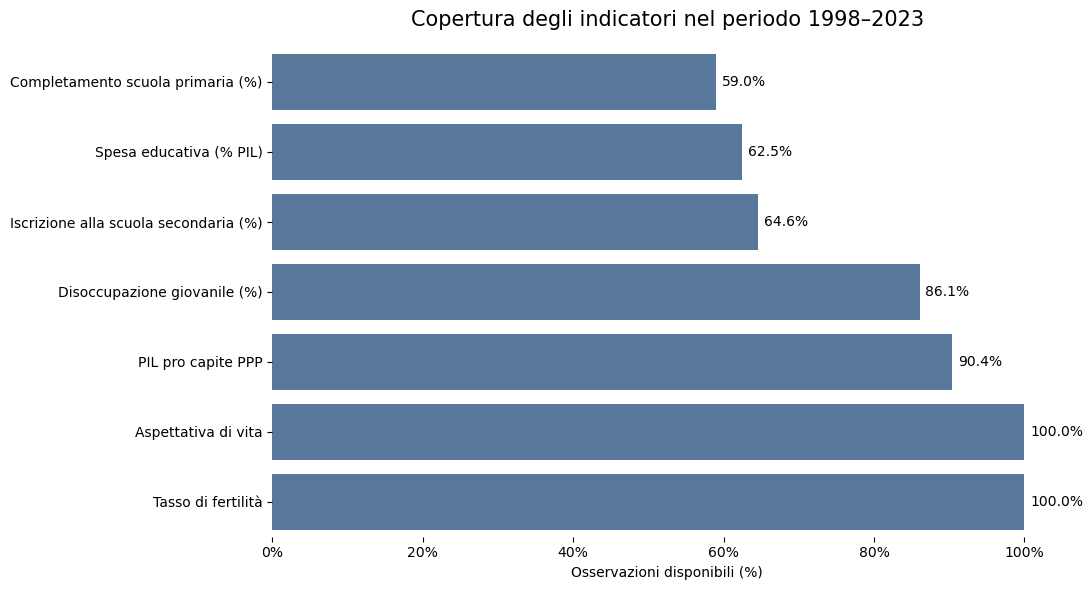

In [30]:
#Sostituisco i nomi tecnici delle variabili con etichette più leggibili, sfruttando l'assegnazione creata in precedenza
variable_coverage["variable_label"] = (variable_coverage["variable"].map(VARIABLE_LABELS))

#Ordino le variabili dalla copertura più bassa alla più alta
variable_coverage = variable_coverage.sort_values("coverage_pct",ascending=True)

#Creo il grafico
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(x="coverage_pct",y="variable_label",data=variable_coverage,color="#4C78A8",ax=ax)

#Aggiungo la percentuale sopra ogni barra
ax.bar_label(ax.containers[0],fmt="%.1f%%",padding=4)

#Personalizzo il grafico
ax.set_title("Copertura degli indicatori nel periodo 1998–2023",fontsize=15,pad=15)

ax.set_xlabel("Osservazioni disponibili (%)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{value:.0f}%"))

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

La copertura varia sensibilmente tra gli indicatori. Aspettativa di vita e fertilità presentano una disponibilità molto elevata, mentre il completamento della scuola primaria, la spesa educativa e l’iscrizione alla scuola secondaria mostrano una maggiore presenza di valori mancanti.

Le analisi successive utilizzeranno quindi le osservazioni disponibili per ciascuna specifica coppia di variabili, evitando di eliminare globalmente tutte le righe che contengono almeno un valore mancante.

### Copertura degli indicatori per regione
Voglio verificare se la disponibilità dei dati è distribuita uniformemente tra le regioni della World Bank.
Per ogni combinazione regione-indicatore calcolo la percentuale di osservazioni Paese-anno non mancanti nel periodo 1998–2023.
La heatmap consente di individuare rapidamente le regioni e le variabili caratterizzate dalle maggiori lacune informative.

Le tonalità più scure indicano una copertura maggiore, mentre quelle più chiare segnalano una presenza più elevata di dati mancanti.
Il numero di economie appartenenti a ciascuna regione viene riportato accanto al nome della regione, poiché gruppi di dimensioni differenti producono percentuali basate su numerosità diverse.

Questa analisi non misura le performance educative o socioeconomiche delle regioni, ma la qualità della base informativa disponibile.

In [31]:
#Calcolo, per ogni regione e indicatore, la percentuale di osservazioni Paese-anno per le quali il dato è disponibile.
regional_variable_coverage = (panel_analysis.groupby("region")[analysis_columns].agg(lambda indicator_values: indicator_values.notna().mean() * 100).round(1))

#Calcolo il numero di economie presenti in ciascuna regione.
#Questa informazione permette di interpretare correttamente percentuali ottenute da gruppi di dimensioni differenti.
economies_per_region = (panel_analysis.groupby("region")["country_code"].nunique())

#Ordino le regioni dalla copertura media più bassa alla copertura media più elevata, così da evidenziare immediatamente le aree con maggiori lacune informative.
region_order_by_coverage = (regional_variable_coverage.mean(axis=1).sort_values(ascending=True).index)

regional_variable_coverage = (regional_variable_coverage.loc[region_order_by_coverage])

regional_variable_coverage

,education_spending_pct_gdp,primary_completion_pct,secondary_enrollment_gross_pct,gdp_per_capita_ppp,youth_unemployment_pct,life_expectancy_years,fertility_rate
region,,,,,,,
North America,60.3,24.4,59.0,100.0,66.7,100.0,100.0
East Asia & Pacific,48.3,47.8,54.0,83.8,78.4,100.0,100.0
Latin America & Caribbean,64.9,61.2,68.3,87.3,73.8,100.0,100.0
"Middle East, North Africa, Afghanistan & Pakistan",50.2,63.9,66.7,92.6,99.8,100.0,100.0
Europe & Central Asia,68.0,61.4,73.6,90.1,84.4,100.0,100.0
Sub-Saharan Africa,68.7,61.9,55.9,95.8,97.8,100.0,100.0
South Asia,80.8,66.0,82.1,100.0,100.0,100.0,100.0


In [32]:
#Creo una copia destinata esclusivamente alla visualizzazione, mantenendo invariato il DataFrame con i nomi tecnici.
regional_coverage_for_plot = (regional_variable_coverage.rename(columns=VARIABLE_LABELS).copy())

#Aggiungo al nome di ogni regione il numero di economie sulle quali viene calcolata la relativa percentuale.
regional_coverage_for_plot.index = [
    f"{region} (n={economies_per_region.loc[region]})"
    for region in regional_coverage_for_plot.index
]

regional_coverage_for_plot

,Spesa educativa (% PIL),Completamento scuola primaria (%),Iscrizione alla scuola secondaria (%),PIL pro capite PPP,Disoccupazione giovanile (%),Aspettativa di vita,Tasso di fertilità
North America (n=3),60.3,24.4,59.0,100.0,66.7,100.0,100.0
East Asia & Pacific (n=37),48.3,47.8,54.0,83.8,78.4,100.0,100.0
Latin America & Caribbean (n=42),64.9,61.2,68.3,87.3,73.8,100.0,100.0
"Middle East, North Africa, Afghanistan & Pakistan (n=23)",50.2,63.9,66.7,92.6,99.8,100.0,100.0
Europe & Central Asia (n=58),68.0,61.4,73.6,90.1,84.4,100.0,100.0
Sub-Saharan Africa (n=48),68.7,61.9,55.9,95.8,97.8,100.0,100.0
South Asia (n=6),80.8,66.0,82.1,100.0,100.0,100.0,100.0


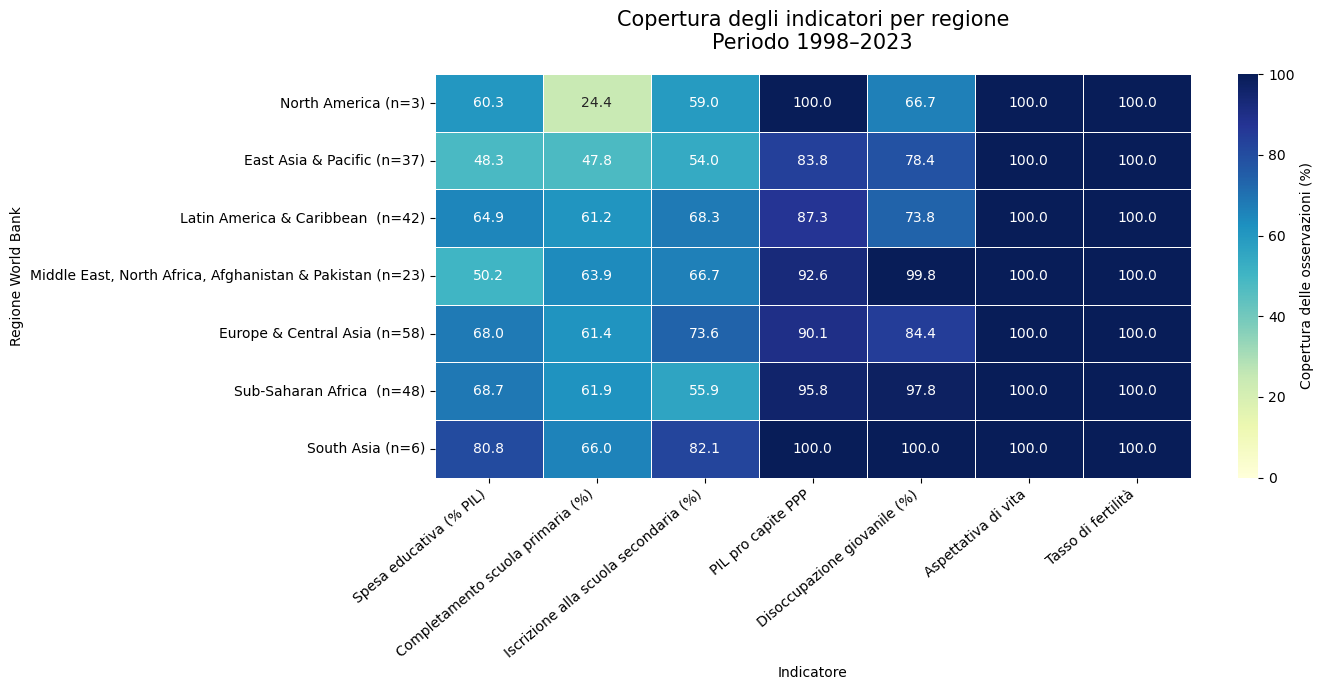

In [33]:
#Creo la figura che conterrà la heatmap.
fig, ax = plt.subplots(figsize=(14, 7))

#Ogni cella rappresenta la percentuale di valori disponibili per una specifica combinazione regione-indicatore.
sns.heatmap(
    regional_coverage_for_plot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Copertura delle osservazioni (%)"
    },
    ax=ax
)

ax.set_title(
    "Copertura degli indicatori per regione\n"
    f"Periodo {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR}",
    fontsize=15,
    pad=18
)

ax.set_xlabel("Indicatore")
ax.set_ylabel("Regione World Bank")

#Ruoto le etichette per evitare sovrapposizioni e mantenere leggibili i nomi degli indicatori.
ax.set_xticklabels(ax.get_xticklabels(),rotation=40, horizontalalignment="right")

plt.tight_layout()
plt.show()


La heatmap evidenzia una copertura molto eterogenea tra indicatori e regioni.
Aspettativa di vita e fertilità risultano completamente disponibili in tutte le aree, mentre il PIL pro capite e la disoccupazione giovanile presentano livelli generalmente elevati di copertura.
Le principali lacune riguardano invece gli indicatori educativi.

East Asia & Pacific mostra una disponibilità inferiore al 55% per spesa educativa, completamento della primaria e iscrizione secondaria.
La spesa educativa presenta inoltre una copertura limitata in Middle East, North Africa, Afghanistan & Pakistan, mentre in Sub-Saharan Africa la principale criticità riguarda l’iscrizione alla scuola secondaria.
North America registra una copertura particolarmente bassa per il completamento della primaria, pari al 24,4%, ma tale percentuale deve essere interpretata considerando che la regione comprende solamente tre economie.

Analogamente, i valori elevati di South Asia si basano su un gruppo di sei economie.
I risultati mostrano che i dati mancanti non sono distribuiti casualmente e potrebbero influenzare i confronti regionali e le correlazioni.
Le analisi relative agli indicatori educativi dovranno quindi riportare la numerosità effettiva del campione e utilizzare le osservazioni disponibili per ciascuna specifica relazione.
Dal punto di vista operativo, il miglioramento della raccolta dei dati dovrebbe concentrarsi soprattutto sul completamento della primaria, sulla spesa educativa e sull’iscrizione secondaria nelle regioni con copertura più bassa.

### Matrice di correlazione tra gli indicatori

Calcolo la correlazione di Spearman tra le variabili numeriche del panel. Questo coefficiente misura l’intensità e la direzione delle relazioni monotone ed è meno sensibile agli outlier rispetto alla correlazione di Pearson.

Le correlazioni vengono calcolate utilizzando, per ogni coppia di variabili, le osservazioni disponibili in entrambe.

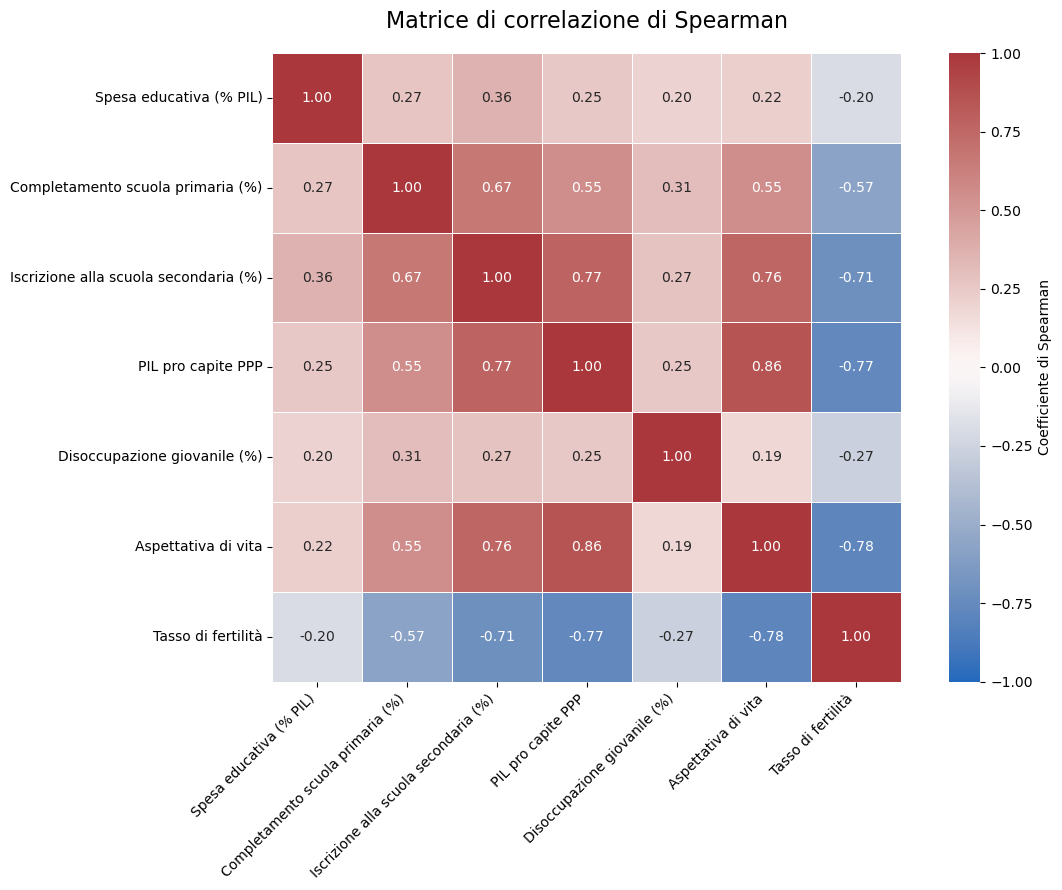

In [34]:
#Calcolo la matrice di correlazione di Spearman.
#min_periods richiede almeno 100 osservazioni valide per ogni correlazione.

correlation_matrix = (panel_analysis[analysis_columns].corr(method="spearman",min_periods=100))

#Rinomino righe e colonne per rendere la matrice più leggibile
correlation_matrix = correlation_matrix.rename(index=VARIABLE_LABELS,columns=VARIABLE_LABELS)

#Creo la heatmap
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.6,
    cbar_kws={
        "label": "Coefficiente di Spearman"
    },
    ax=ax
)

#Personalizzo il grafico
ax.set_title("Matrice di correlazione di Spearman",fontsize=16,pad=18)

ax.set_xticklabels(ax.get_xticklabels(),rotation=45,horizontalalignment="right")

plt.tight_layout()
plt.show()

La matrice di Spearman evidenzia che la spesa educativa in percentuale del PIL presenta correlazioni positive ma deboli o moderate con il completamento
della scuola primaria (0,27), l’iscrizione alla scuola secondaria (0,36), il PIL pro capite (0,25) e l’aspettativa di vita (0,22),
mentre mostra una debole correlazione negativa con il tasso di fertilità (-0,20).

Le associazioni più forti riguardano il PIL pro capite e l’aspettativa di vita (0,86), l’iscrizione alla scuola secondaria e il PIL pro capite (0,77),
nonché l’iscrizione alla scuola secondaria e l’aspettativa di vita (0,76).
    
Il tasso di fertilità risulta invece fortemente e negativamente associato all’aspettativa di vita (-0,78), al PIL pro capite (-0,77)
e all’iscrizione secondaria (-0,71).

La disoccupazione giovanile mostra correlazioni generalmente deboli con tutte le altre variabili.
Questi risultati suggeriscono l’esistenza di relazioni tra istruzione, sviluppo economico, salute e dinamiche demografiche,
ma non dimostrano rapporti di causa-effetto: le correlazioni potrebbero dipendere anche da differenze strutturali tra Paesi, regioni e livelli di reddito, che saranno approfondite nelle analisi successive.

## Analisi delle relazioni tra istruzione e sviluppo socioeconomico

### Spesa educativa e risultati educativi

L’obiettivo principale dell’analisi è verificare se una maggiore spesa pubblica per l’istruzione sia associata a risultati educativi migliori.
Vengono considerati due indicatori complementari: il completamento della scuola primaria, che rappresenta un risultato effettivo del percorso scolastico, e l’iscrizione alla scuola secondaria, che misura invece il livello di partecipazione al sistema educativo.

Poiché gli investimenti nell’istruzione possono richiedere tempo prima di produrre risultati osservabili, la spesa educativa nell’anno `t` viene confrontata con ciascun risultato nello stesso anno, dopo tre anni e dopo cinque anni.
Per ogni intervallo viene calcolata sia la correlazione complessiva tra tutte le osservazioni Paese-anno, sia la correlazione tra gli scostamenti dalla media di ciascun Paese.
    
Il secondo calcolo permette di verificare se, quando un Paese spende più rispetto al proprio livello abituale, anche i risultati educativi futuri tendono a essere superiori alla propria media.

Il coefficiente utilizzato è quello di Spearman, coerentemente con le analisi precedenti. L’analisi ritardata migliora l’ordinamento temporale tra investimento e risultato, ma non permette da sola di dimostrare un rapporto causale.

In [35]:
#Definisco i risultati educativi da mettere in relazione con la spesa. Il dizionario associa il nome tecnico della colonna a un'etichetta leggibile.
EDUCATIONAL_OUTCOMES = {
    "primary_completion_pct": "Completamento della scuola primaria (%)",
    "secondary_enrollment_gross_pct": "Iscrizione alla scuola secondaria (%)"
}

#Confronto la spesa con i risultati osservati nello stesso anno, dopo tre anni e dopo cinque anni.
EDUCATION_LAGS = [0, 3, 5]

#Per l'analisi interna ai Paesi mantengo solamente quelli con almeno tre coppie valide di osservazioni per ciascun risultato e ritardo.
MIN_VALID_PAIRS_PER_COUNTRY = 3

#Preparo il DataFrame della spesa e distinguo esplicitamente l'anno dell'investimento dall'anno in cui sarà osservato il risultato.
education_spending_by_year = (panel_analysis[["country_code","country","year","education_spending_pct_gdp"]]
    .rename(columns={"year": "spending_year","education_spending_pct_gdp": "spending_pct_gdp"}).copy())

education_spending_by_year.head()

,country_code,country,spending_year,spending_pct_gdp
0,ABW,Aruba,1998,4.76316
1,ABW,Aruba,1999,4.39527
2,ABW,Aruba,2000,4.71468
3,ABW,Aruba,2001,4.79898
4,ABW,Aruba,2002,4.87220


In [36]:
#In questa lista salverò i risultati calcolati per ogni indicatore, ritardo temporale e tipo di confronto.
lagged_correlation_rows = []

for outcome_column, outcome_label in EDUCATIONAL_OUTCOMES.items():

    #Preparo l'indicatore educativo conservando il suo anno originale.
    educational_outcome_by_year = (panel_analysis[["country_code","year",outcome_column]].rename(columns={"year": "outcome_year",outcome_column: "outcome_value"}).copy())

    for lag_years in EDUCATION_LAGS:

        #Associo al risultato osservato nell'anno t + lag l'anno t nel quale è stata misurata la spesa.
        shifted_outcome = educational_outcome_by_year.copy()

        shifted_outcome["spending_year"] = (shifted_outcome["outcome_year"] - lag_years)

        #Unisco la spesa nell'anno t al risultato dello stesso Paese osservato dopo il numero di anni stabilito.
        paired_country_years = education_spending_by_year.merge(shifted_outcome,on=["country_code", "spending_year"],how="inner",validate="one_to_one"        )

        #Applico una rimozione pairwise: elimino solamente le righe prive della spesa o del risultato richiesto.
        paired_country_years = (paired_country_years.dropna(subset=["spending_pct_gdp","outcome_value"]).copy())

        #Calcolo la correlazione complessiva su tutte le osservazioni Paese-anno disponibili.
        pooled_spearman_rho = paired_country_years["spending_pct_gdp"].corr(paired_country_years["outcome_value"],method="spearman")

        lagged_correlation_rows.append({
                "outcome": outcome_label,
                "lag_years": lag_years,
                "analysis_type": "Confronto complessivo",
                "spearman_rho": pooled_spearman_rho,
                "observations": len(paired_country_years),
                "countries": paired_country_years["country_code"].nunique()
            }
        )

        # Conto quante coppie valide possiede ciascun Paese.
        valid_pairs_per_country = (paired_country_years.groupby("country_code")["outcome_value"].transform("size"))

        #Controllo che, all'interno di ogni Paese, entrambe le variabili presentino una variazione effettiva nel tempo.
        spending_values_per_country = (paired_country_years.groupby("country_code")["spending_pct_gdp"].transform("nunique"))

        outcome_values_per_country = (paired_country_years.groupby("country_code")["outcome_value"].transform("nunique"))

        within_country_data = paired_country_years.loc[
            (valid_pairs_per_country >= MIN_VALID_PAIRS_PER_COUNTRY)
            & (spending_values_per_country > 1)
            & (outcome_values_per_country > 1)
        ].copy()

        #Sottraggo a ogni valore la media del relativo Paese.
        #In questo modo considero quanto ciascuna osservazione si discosta dal livello abituale del Paese, riducendo il peso delle differenze strutturali permanenti tra economie diverse.
        within_country_data["spending_deviation"] = (within_country_data["spending_pct_gdp"]- within_country_data.groupby("country_code")["spending_pct_gdp"].transform("mean"))

        within_country_data["outcome_deviation"] = (within_country_data["outcome_value"]- within_country_data.groupby("country_code")["outcome_value"].transform("mean"))

        within_country_spearman_rho = within_country_data["spending_deviation"].corr(within_country_data["outcome_deviation"],method="spearman")
        
        lagged_correlation_rows.append(
            {
                "outcome": outcome_label,
                "lag_years": lag_years,
                "analysis_type": "Scostamenti dalla media del Paese",
                "spearman_rho": within_country_spearman_rho,
                "observations": len(within_country_data),
                "countries": within_country_data[
                    "country_code"
                ].nunique()
            }
        )

#Trasformo i risultati raccolti in un DataFrame.
lagged_correlation_results = pd.DataFrame(lagged_correlation_rows)

lagged_correlation_results

,outcome,lag_years,analysis_type,spearman_rho,observations,countries
0,Completamento della scuola primaria (%),0,Confronto complessivo,0.268815,2481,184
1,Completamento della scuola primaria (%),0,Scostamenti dalla media del Paese,0.144442,2467,174
2,Completamento della scuola primaria (%),3,Confronto complessivo,0.278666,2246,181
3,Completamento della scuola primaria (%),3,Scostamenti dalla media del Paese,0.111522,2226,169
4,Completamento della scuola primaria (%),5,Confronto complessivo,0.271962,2007,178
5,Completamento della scuola primaria (%),5,Scostamenti dalla media del Paese,0.088075,1988,166
6,Iscrizione alla scuola secondaria (%),0,Confronto complessivo,0.364494,2656,194
7,Iscrizione alla scuola secondaria (%),0,Scostamenti dalla media del Paese,0.128193,2632,179
8,Iscrizione alla scuola secondaria (%),3,Confronto complessivo,0.390600,2407,194
9,Iscrizione alla scuola secondaria (%),3,Scostamenti dalla media del Paese,0.161936,2382,176


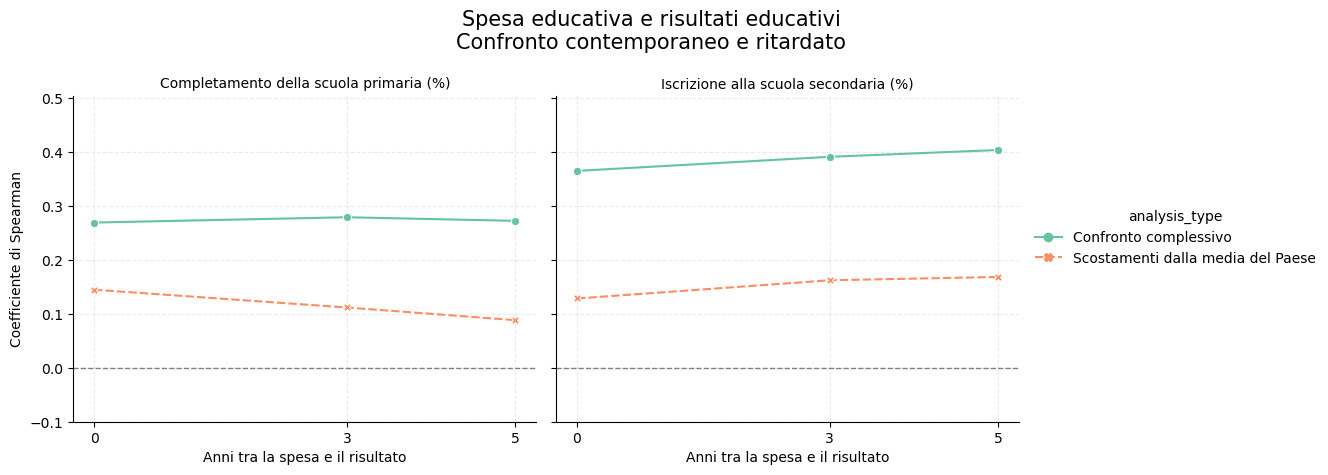

In [37]:
# Definisco l'ordine delle due serie nella legenda.
ANALYSIS_TYPE_ORDER = [
    "Confronto complessivo",
    "Scostamenti dalla media del Paese"
]

#Creo due pannelli, uno per ciascun risultato educativo. Ogni linea mostra come cambia la correlazione quando aumenta la distanza temporale tra la spesa e il risultato.
lagged_correlation_grid = sns.relplot(
    data=lagged_correlation_results,
    x="lag_years",
    y="spearman_rho",
    col="outcome",
    col_order=list(EDUCATIONAL_OUTCOMES.values()),
    hue="analysis_type",
    hue_order=ANALYSIS_TYPE_ORDER,
    style="analysis_type",
    style_order=ANALYSIS_TYPE_ORDER,
    kind="line",
    markers=True,
    dashes=True,
    palette="Set2",
    height=4.8,
    aspect=1.1,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

lagged_correlation_grid.set_axis_labels("Anni tra la spesa e il risultato","Coefficiente di Spearman")

lagged_correlation_grid.set_titles("{col_name}")

#Calcolo limiti comuni che comprendano tutti i coefficienti e mantengano visibile il valore zero.
minimum_rho = lagged_correlation_results["spearman_rho"].min()

maximum_rho = lagged_correlation_results["spearman_rho"].max()

lower_limit = max(-1,min(-0.10, minimum_rho - 0.10))

upper_limit = min(1,max(0.10, maximum_rho + 0.10))

for axis in lagged_correlation_grid.axes.flat:

    # La linea orizzontale indica l'assenza di correlazione.
    axis.axhline(
        y=0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    axis.set_xticks(EDUCATION_LAGS)
    axis.set_ylim(lower_limit, upper_limit)

    axis.grid(True,linestyle="--",alpha=0.25)

lagged_correlation_grid.figure.suptitle("Spesa educativa e risultati educativi\n"
    "Confronto contemporaneo e ritardato",
    fontsize=15
)

lagged_correlation_grid.figure.subplots_adjust(top=0.80)

plt.show()

L’analisi mostra associazioni positive tra la spesa educativa e i due risultati considerati, ma con intensità e andamenti differenti.
Per il completamento della scuola primaria, la correlazione complessiva rimane stabile intorno a 0,27 anche introducendo ritardi di tre e cinque anni.
La correlazione calcolata sugli scostamenti dalla media di ciascun Paese è invece più debole e diminuisce da circa 0,14 a 0,09.
Non emerge quindi una chiara evidenza che l’associazione con il completamento della primaria diventi più forte nel tempo.

Per l’iscrizione alla scuola secondaria, la correlazione complessiva aumenta da circa 0,36 nello stesso anno a circa 0,40 dopo cinque anni.
Anche l’associazione interna ai Paesi cresce, seppure più debolmente, da circa 0,13 a 0,17.
Questo andamento è compatibile con l’ipotesi che gli investimenti educativi possano essere associati a un aumento graduale della partecipazione alla scuola secondaria.

In entrambi i pannelli, le correlazioni complessive sono sensibilmente superiori a quelle calcolate sugli scostamenti interni ai Paesi.
Questo indica che una parte importante della relazione deriva dalle differenze strutturali tra economie, mentre le variazioni della spesa all’interno dello stesso Paese mostrano associazioni più contenute.
I risultati descrivono pertanto associazioni e non dimostrano un effetto causale della spesa.

### Distribuzione geografica della spesa educativa

Analizziamo come si distribuisce la spesa in educazione, sulla base del PIL, a livello geografico. 
L'obiettivo è mappare i Paesi che destinano all’istruzione una quota maggiore del proprio PIL, considerando che l'investimento è slegato dalla qualità delle risorse che possono essere offerte

In [38]:
#Scelgo l'anno da rappresentare, in questo caso il 2022 perchè è uno di quelli con più valori presenti nel dataset
MAP_YEAR = 2022

#Seleziono le osservazioni relative all'anno scelto
map_data = (
    panel_analysis.loc[panel_analysis["year"].eq(MAP_YEAR),["country_code","country","region","income_level","education_spending_pct_gdp"]]
    #Escludo i Paesi per i quali la spesa educativa non è disponibile
    .dropna(subset=["education_spending_pct_gdp"]).copy())

map_data.head()

,country_code,country,region,income_level,education_spending_pct_gdp
76,AGO,Angola,Sub-Saharan Africa,Lower middle income,2.385359
102,ALB,Albania,Europe & Central Asia,Upper middle income,2.729780
128,AND,Andorra,Europe & Central Asia,High income,2.647280
180,ARG,Argentina,Latin America & Caribbean,Upper middle income,4.792630
206,ARM,Armenia,Europe & Central Asia,Upper middle income,2.491900


In [39]:
#Numero complessivo di economie presenti nel dataset per l'anno scelto
economies_total = panel_analysis.loc[panel_analysis["year"].eq(MAP_YEAR),"country_code"].nunique()

#Numero di economie con un valore disponibile
economies_mapped = map_data["country_code"].nunique()

#Percentuale di copertura della mappa
map_coverage_pct = economies_mapped / economies_total * 100

print(f"Anno rappresentato: {MAP_YEAR}")
print(f"Economie rappresentate: {economies_mapped} su {economies_total}")
print(f"Copertura: {map_coverage_pct:.1f}%")

Anno rappresentato: 2022
Economie rappresentate: 164 su 217
Copertura: 75.6%


In [40]:
fig = px.choropleth(
    data_frame=map_data,

    #Plotly utilizza il codice ISO-3 per identificare ogni Paese
    locations="country_code",
    locationmode="ISO-3",

    #La colorazione dipende dalla spesa educativa
    color="education_spending_pct_gdp",

    #Informazioni mostrate passando il mouse sulla mappa
    hover_name="country",
    hover_data={
        "country_code": False,
        "region": True,
        "income_level": True,
        "education_spending_pct_gdp": ":.2f"
    },

    #Scala sequenziale: colori più scuri indicano valori più elevati
    color_continuous_scale="YlGnBu",

    labels={
        "education_spending_pct_gdp": "Spesa educativa (% PIL)",
        "region": "Regione",
        "income_level": "Livello di reddito"
    },

    title=(
        f"Spesa pubblica per l'istruzione nel {MAP_YEAR}"
        f"<br><sup>Copertura: {economies_mapped} economie su "
        f"{economies_total} ({map_coverage_pct:.1f}%)</sup>"
    )
)

#Personalizzo l'aspetto geografico
fig.update_geos(
    projection_type="natural earth",
    showframe=False,
    showcoastlines=True,
    coastlinecolor="white",
    showland=True,

    #I Paesi senza dati vengono visualizzati in grigio
    landcolor="lightgray"
)

fig.update_layout(
    coloraxis_colorbar_title="Spesa educativa<br>(% del PIL)",
    margin={"r": 0, "t": 90, "l": 0, "b": 0}
)

fig.show()

La mappa mostra la distribuzione geografica della spesa pubblica per l’istruzione, espressa come percentuale del PIL, nell’anno selezionato. Le tonalità più scure identificano i Paesi che destinano all’istruzione una quota maggiore del proprio PIL, mentre le aree grigie indicano l’assenza di dati. La percentuale di spesa non misura direttamente né l’ammontare assoluto delle risorse investite né la loro efficacia: Paesi con economie molto diverse possono destinare la stessa percentuale del PIL all’istruzione, ma disporre di risorse per studente notevolmente differenti.

### Iscrizione alla scuola secondaria e sviluppo economico

L’analisi serve a verificare l’ipotesi, secondo cui, una maggiore partecipazione alla scuola secondaria è associata a livelli più elevati di sviluppo economico.
Ogni punto rappresenta un’osservazione Paese-anno del periodo analizzato.
Il colore distingue i Paesi in base al livello di reddito e permette di valutare se la relazione complessiva dipende anche dalle differenze strutturali tra gruppi economici.
Il PIL pro capite viene rappresentato su scala logaritmica perché presenta valori molto distanti tra loro.
Si utilizza il coefficiente di Spearman poiché misura una relazione monotona senza richiedere che essa sia lineare e risulta meno sensibile ai valori estremi rispetto alla correlazione di Pearson.

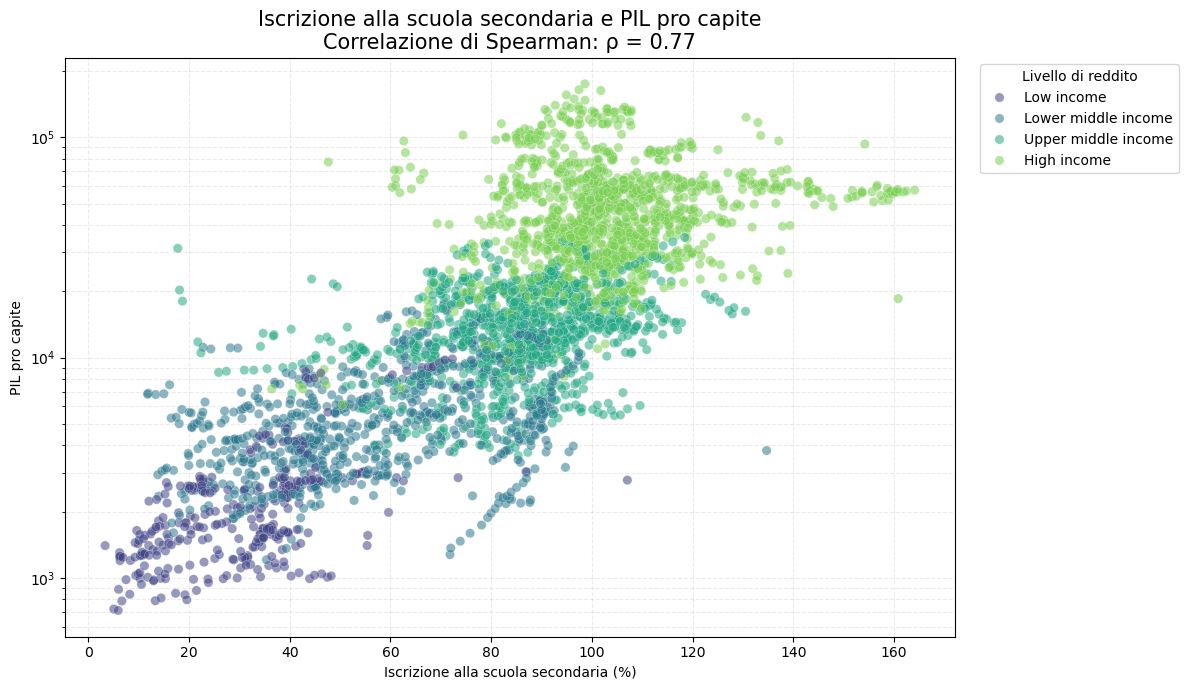

In [41]:
#Seleziono le variabili necessarie per identificare ogni osservazione Paese-anno e il relativo livello di reddito,
#elimino le osservazioni mancanti per le due variabili analizzate
scatter_data = (panel_analysis[["country","year","income_level","secondary_enrollment_gross_pct","gdp_per_capita_ppp"]]
                .dropna(subset=["secondary_enrollment_gross_pct","gdp_per_capita_ppp"]).copy())

#La scala logaritmica richiede valori del PIL maggiori di zero, altrimenti non potrei rappresentare correttamente i valori
scatter_data = scatter_data[scatter_data["gdp_per_capita_ppp"]>0]

#Calcolo la correlazione di Spearman sulle osservazioni rappresentate
spearman_rho = scatter_data[["secondary_enrollment_gross_pct","gdp_per_capita_ppp"]].corr(method="spearman").iloc[0, 1]

#Ordino le categorie di reddito dalla più bassa alla più alta, in questo modo la legenda sarà più intuitiva

income_order = ["Low income","Lower middle income","Upper middle income","High income"]

#Creo lo scatter plot, ogni punto rappresenterà un'osservazione Paese-anno.
#Il colore identifica la fascia di reddito, la trasparenza permette di ridurre il problema della sovrapposizione dei punti
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=scatter_data,
    x="secondary_enrollment_gross_pct",
    y="gdp_per_capita_ppp",
    hue="income_level",
    hue_order=income_order,
    palette="viridis",
    alpha=0.55,
    s=45,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

#Utilizzo una scala logaritmica perché il PIL pro capite presenta valori molto differenti tra i Paesi.
#Questo mi serve per avere una migliore visualizzazione.
ax.set_yscale("log")

ax.set_title("Iscrizione alla scuola secondaria e PIL pro capite\n"f"Correlazione di Spearman: ρ = {spearman_rho:.2f}",fontsize=15)

ax.set_xlabel("Iscrizione alla scuola secondaria (%)")
ax.set_ylabel("PIL pro capite")

ax.legend(title="Livello di reddito",bbox_to_anchor=(1.02, 1),loc="upper left")

ax.grid(True, which="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

Il coefficiente di Spearman pari a 0,77 indica una forte associazione monotona positiva: nel campione analizzato, livelli più elevati di iscrizione alla scuola secondaria tendono a essere accompagnati da un PIL pro capite maggiore.
Il grafico evidenzia inoltre una marcata suddivisione per livello di reddito: i Paesi ad alto reddito si concentrano prevalentemente nella parte superiore destra, mentre quelli a basso reddito si trovano soprattutto nella parte inferiore sinistra.

La separazione tra questi gruppi suggerisce che una parte della correlazione complessiva potrebbe dipendere dalle differenze strutturali tra livelli di reddito; sarà quindi utile verificare successivamente la relazione anche all’interno dei singoli gruppi.
    
I valori dell’iscrizione superiori al 100% non costituiscono necessariamente errori, poiché l’indicatore è un tasso lordo e comprende anche studenti di età diversa da quella ufficialmente prevista.

Nel campione analizzato, i Paesi con un PIL pro capite più elevato tendono a presentare livelli maggiori di iscrizione lorda alla scuola secondaria.
Il risultato è coerente con l’ipotesi che una maggiore disponibilità di risorse economiche favorisca l’accesso all’istruzione.

Tuttavia, sebbene il grafico mostra una forte associazione positiva tra sviluppo economico e partecipazione alla scuola secondaria,
questa evidenza sostiene, ma non dimostra da sola, l’ipotesi che una maggiore disponibilità economica favorisca le opportunità educative.

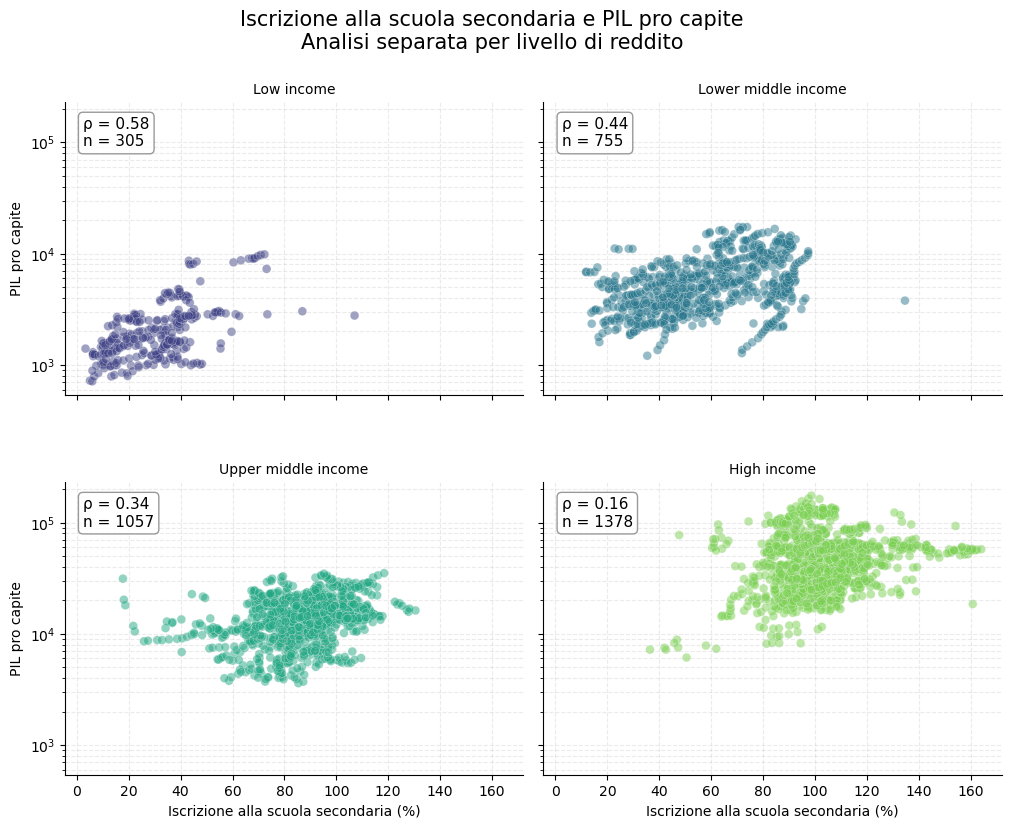

In [42]:
#Definisco un ordine economico coerente per i pannelli, dal livello di reddito più basso a quello più alto.
income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]

#Mantengo solamente le categorie previste nell'analisi.
income_level_data = scatter_data[scatter_data["income_level"].isin(income_order)].copy()

#Creo un pannello separato per ogni livello di reddito.
#Gli assi vengono condivisi per rendere i gruppi direttamente confrontabili.
income_scatter_grid = sns.relplot(
    data=income_level_data,
    x="secondary_enrollment_gross_pct",
    y="gdp_per_capita_ppp",
    col="income_level",
    col_order=income_order,
    col_wrap=2,
    hue="income_level",
    hue_order=income_order,
    palette="viridis",
    kind="scatter",
    alpha=0.50,
    s=40,
    edgecolor="white",
    linewidth=0.3,
    legend=False,
    height=4.2,
    aspect=1.25,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

#Applico la stessa scala logaritmica del grafico complessivo.
income_scatter_grid.set(yscale="log")

income_scatter_grid.set_axis_labels("Iscrizione alla scuola secondaria (%)","PIL pro capite")

income_scatter_grid.set_titles("{col_name}")

#Calcolo e mostro in ogni pannello la correlazione di Spearman e il numero di osservazioni disponibili per quel gruppo.
for ax, income_level in zip(income_scatter_grid.axes.flat, income_order):

    group_data = income_level_data[income_level_data["income_level"] == income_level]

    group_rho = group_data["secondary_enrollment_gross_pct"].corr(group_data["gdp_per_capita_ppp"],method="spearman")

    group_n = len(group_data)

    ax.text(
        0.04,
        0.95,
        f"ρ = {group_rho:.2f}\nn = {group_n}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.80,
            "edgecolor": "gray"
        }
    )

    ax.grid(
        True,
        which="both",
        linestyle="--",
        alpha=0.25
    )

income_scatter_grid.figure.suptitle(
    "Iscrizione alla scuola secondaria e PIL pro capite\n"
    "Analisi separata per livello di reddito",
    fontsize=15
)

income_scatter_grid.figure.subplots_adjust(
    top=0.87,
    hspace=0.30
)

plt.show()

L’analisi separata per livello di reddito mostra che la relazione tra iscrizione alla scuola secondaria e PIL pro capite rimane positiva in tutti i gruppi, ma presenta intensità differenti.
    
La correlazione è moderatamente forte nei Paesi a basso reddito (ρ = 0,58), moderata nei Paesi a reddito medio-basso (ρ = 0,44), più contenuta nei Paesi a reddito medio-alto (ρ = 0,34) e molto debole nei Paesi ad alto reddito (ρ = 0,16).
Il confronto con la correlazione complessiva (ρ = 0,77) indica che quest’ultima è in parte amplificata dalle differenze strutturali tra i livelli di reddito.
    
Quindi la separazione tra Paesi economicamente più e meno sviluppati contribuisce sensibilmente alla forte relazione osservata nel grafico aggregato, sebbene l’associazione non dipenda esclusivamente da questa separazione.
La progressiva riduzione della correlazione potrebbe essere collegata a un effetto di saturazione: nei Paesi ad alto reddito l’iscrizione secondaria è già generalmente elevata e presenta una variabilità più limitata, mentre il PIL pro capite continua a differire considerevolmente.
Di conseguenza, ulteriori differenze di reddito non corrispondono necessariamente ad aumenti altrettanto evidenti nell’iscrizione.
Questa spiegazione rappresenta però un’ipotesi interpretativa e non una conclusione causale.

I risultati devono inoltre essere letti considerando che i gruppi hanno numerosità differenti e che ogni Paese compare più volte nel dataset, una volta per ciascun anno disponibile.
Le osservazioni non sono quindi completamente indipendenti e la relazione potrebbe essere influenzata anche dai trend temporali e da altre caratteristiche strutturali dei Paesi.

### Iscrizione alla scuola secondaria e aspettativa di vita
Si analizza la relazione tra la partecipazione alla scuola secondaria e l’aspettativa di vita, utilizzata come indicatore sintetico delle condizioni sanitarie e sociali di un Paese.
L’ipotesi è che livelli più elevati di iscrizione scolastica siano associati a una maggiore aspettativa di vita.

Poiché il dataset contiene numerose osservazioni Paese-anno, un normale scatter plot potrebbe presentare una forte sovrapposizione dei punti.
Si utilizza quindi un hexbin plot, che raggruppa le osservazioni in celle esagonali e rappresenta attraverso il colore la loro densità.
La relazione viene sintetizzata mediante il coefficiente di Spearman, adatto a misurare associazioni monotone senza presupporre una relazione perfettamente lineare.

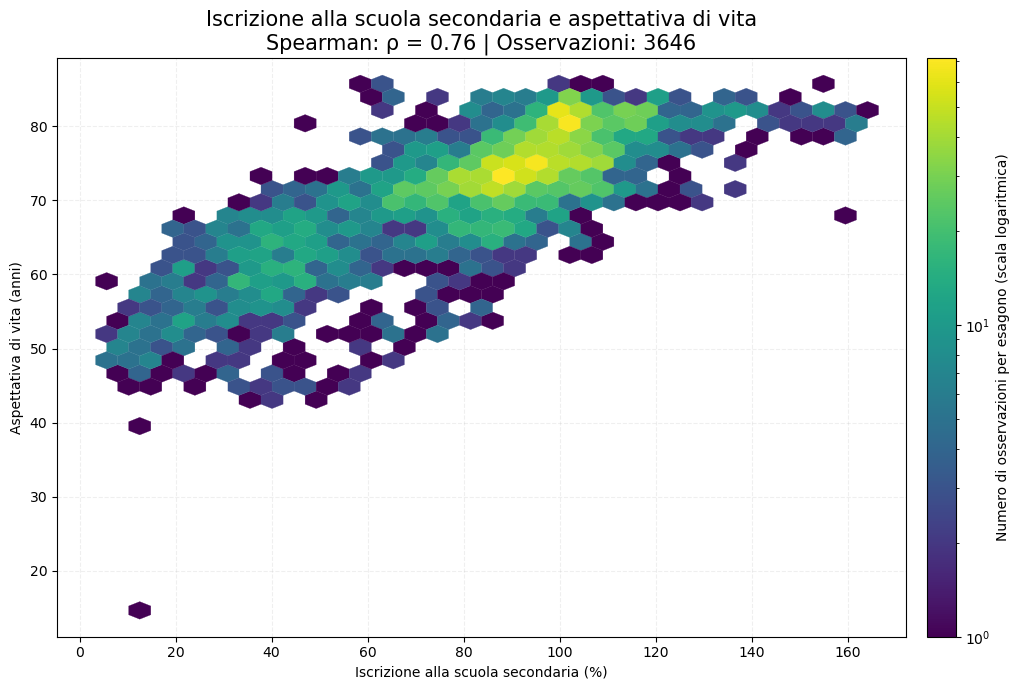

In [43]:
#Costruisco il campione mantenendo solamente le osservazioni per le quali entrambe le variabili analizzate sono disponibili.
life_expectancy_data = (panel_analysis[["country","year","income_level","secondary_enrollment_gross_pct","life_expectancy_years"]]
                        .dropna(subset=["secondary_enrollment_gross_pct","life_expectancy_years"]).copy())

#Calcolo il coefficiente di Spearman utilizzando esattamente le osservazioni che verranno rappresentate nel grafico.
spearman_rho_life = life_expectancy_data["secondary_enrollment_gross_pct"].corr(life_expectancy_data["life_expectancy_years"],method="spearman")

observation_count_life = len(life_expectancy_data)

#Creo la figura e il relativo sistema di assi.
fig, ax = plt.subplots(figsize=(11, 7))

#Suddivido il piano in celle esagonali.Il colore di ogni esagono rappresenta il numero di osservazioni presenti al suo interno.
#La scala logaritmica evita che le aree più dense rendano poco visibili quelle con meno osservazioni.
hexbin_plot = ax.hexbin(
    x=life_expectancy_data["secondary_enrollment_gross_pct"],
    y=life_expectancy_data["life_expectancy_years"],
    gridsize=35,
    mincnt=1,
    bins="log",
    cmap="viridis",
    linewidths=0.2
)

#Aggiungo una barra cromatica che permette di interpretare la densità delle osservazioni in ogni area del grafico.
colorbar = fig.colorbar(
    hexbin_plot,
    ax=ax,
    pad=0.02
)

colorbar.set_label("Numero di osservazioni per esagono (scala logaritmica)")

ax.set_title(
    "Iscrizione alla scuola secondaria e aspettativa di vita\n"
    f"Spearman: ρ = {spearman_rho_life:.2f} | "
    f"Osservazioni: {observation_count_life}",
    fontsize=15
)

ax.set_xlabel("Iscrizione alla scuola secondaria (%)")
ax.set_ylabel("Aspettativa di vita (anni)")

#Mantengo una griglia leggera come riferimento visivo, collocandola dietro gli esagoni.
ax.set_axisbelow(True)
ax.grid(
    True,
    linestyle="--",
    alpha=0.20
)

plt.tight_layout()
plt.show()

Il grafico presenta una chiara distribuzione crescente: passando da livelli bassi a livelli elevati di iscrizione secondaria, l’aspettativa di vita tende ad aumentare. Questo conferma visivamente la forte correlazione positiva di Spearman, pari a 0,76.

La maggior parte delle osservazion si trova, approssimativamente, tra i 72 e gli 80 anni e tra l'80% e il 110% di iscrizione alla scuola secondaria.

Nella parte superiore destra la relazione sembra progressivamente appiattirsi: oltre determinati livelli di iscrizione, l’aspettativa di vita tende a concentrarsi intorno agli 80 anni.
Questo potrebbe indicare un possibile effetto di saturazione: quando la partecipazione scolastica è già molto elevata, ulteriori incrementi dell’iscrizione non sono necessariamente accompagnati da aumenti altrettanto ampi dell’aspettativa di vita.

La relazione osservata non dimostra che una maggiore iscrizione scolastica causi direttamente un aumento dell’aspettativa di vita.
I due fenomeni potrebbero influenzarsi reciprocamente oppure dipendere da fattori comuni, come reddito, qualità dei servizi sanitari, stabilità istituzionale e livello generale di sviluppo.

### Evoluzione temporale della spesa e dei risultati educativi

Analizziamo l'evoluzione degli indicatori nel periodo 1998–2023.

La figura è composta da due pannelli: il primo rappresenta la mediana annuale della spesa educativa in percentuale del PIL, mentre il secondo mostra la mediana annuale del completamento della scuola primaria.
Ogni linea identifica una regione della World Bank e mantiene lo stesso colore nei due pannelli.

Si utilizza la mediana perché è meno influenzata dai valori estremi rispetto alla media.
Per limitare il rischio di rappresentare risultati basati su campioni troppo piccoli, vengono visualizzate solamente le combinazioni regione-anno per le quali sono disponibili almeno tre economie.
Le eventuali interruzioni delle linee indicano quindi una copertura insufficiente.

I due pannelli devono essere confrontati osservando la direzione e l’andamento delle linee, non il loro livello verticale, poiché le variabili utilizzano scale differenti.
L’analisi permette di individuare differenze regionali, periodi di crescita o rallentamento e possibili movimenti congiunti tra investimento e completamento scolastico, senza implicare necessariamente un rapporto causale.

In [44]:
# Definisco i due indicatori da rappresentare. Il completamento della primaria viene scelto perché misura un risultato effettivo del percorso educativo.
TEMPORAL_INDICATORS = {
    "education_spending_pct_gdp": "Spesa educativa (% PIL)",
    "primary_completion_pct": "Completamento scuola primaria (%)"
}

#Visualizzo un valore regionale solamente quando sono disponibili almeno tre economie per quello specifico anno e indicatore.
MIN_COUNTRIES_PER_REGION_YEAR = 3

#Trasformo i due indicatori da colonne separate a una struttura lunga. Questo formato facilita il raggruppamento per regione, anno e indicatore.
temporal_data_long = panel_analysis.melt(id_vars=["country_code", "country","region","year"],value_vars=list(TEMPORAL_INDICATORS.keys()),var_name="indicator",value_name="indicator_value")

temporal_data_long.head()

,country_code,country,region,year,indicator,indicator_value
0,ABW,Aruba,Latin America & Caribbean,1998,education_spending_pct_gdp,4.76316
1,ABW,Aruba,Latin America & Caribbean,1999,education_spending_pct_gdp,4.39527
2,ABW,Aruba,Latin America & Caribbean,2000,education_spending_pct_gdp,4.71468
3,ABW,Aruba,Latin America & Caribbean,2001,education_spending_pct_gdp,4.79898
4,ABW,Aruba,Latin America & Caribbean,2002,education_spending_pct_gdp,4.87220


In [45]:
# Per ogni combinazione regione-anno-indicatore calcolo:
# - la mediana dei valori disponibili;
# - il numero di economie effettivamente rappresentate.
regional_annual_trends = (temporal_data_long.groupby(["region", "year","indicator"],as_index=False)
                        .agg(regional_median=("indicator_value", "median"),countries_available=("indicator_value", "count")))

#Le osservazioni basate su meno di tre economie non vengono utilizzate nel grafico, ma le righe vengono conservate con NaN.
#In questo modo la linea si interrompe e non collega impropriamente due anni tra i quali non esiste una copertura sufficiente.
regional_annual_trends.loc[regional_annual_trends["countries_available"]< MIN_COUNTRIES_PER_REGION_YEAR,"regional_median"] = np.nan

#Aggiungo un'etichetta leggibile per ciascun indicatore.
regional_annual_trends["indicator_label"] = (regional_annual_trends["indicator"].map(TEMPORAL_INDICATORS))

regional_annual_trends.head()

,region,year,indicator,regional_median,countries_available,indicator_label
0,East Asia & Pacific,1998,education_spending_pct_gdp,3.697460,13,Spesa educativa (% PIL)
1,East Asia & Pacific,1998,primary_completion_pct,92.158524,12,Completamento scuola primaria (%)
2,East Asia & Pacific,1999,education_spending_pct_gdp,5.157155,16,Spesa educativa (% PIL)
3,East Asia & Pacific,1999,primary_completion_pct,94.099918,14,Completamento scuola primaria (%)
4,East Asia & Pacific,2000,education_spending_pct_gdp,5.065770,18,Spesa educativa (% PIL)


In [46]:
#Riassumo la numerosità minima, mediana e massima osservata per ogni indicatore e regione.
temporal_coverage_summary = (regional_annual_trends.groupby(["indicator_label","region"])["countries_available"]
    .agg( minimum_countries="min", median_countries="median", maximum_countries="max").reset_index().round(1))

temporal_coverage_summary

,indicator_label,region,minimum_countries,median_countries,maximum_countries
0,Completamento scuola primaria (%),East Asia & Pacific,12,17.0,24
1,Completamento scuola primaria (%),Europe & Central Asia,4,37.5,47
2,Completamento scuola primaria (%),Latin America & Caribbean,6,26.0,32
3,Completamento scuola primaria (%),"Middle East, North Africa, Afghanistan & Pakistan",7,15.0,18
4,Completamento scuola primaria (%),North America,0,1.0,1
5,Completamento scuola primaria (%),South Asia,2,4.0,6
6,Completamento scuola primaria (%),Sub-Saharan Africa,18,31.0,37
7,Spesa educativa (% PIL),East Asia & Pacific,9,17.0,27
8,Spesa educativa (% PIL),Europe & Central Asia,16,39.5,49
9,Spesa educativa (% PIL),Latin America & Caribbean,16,26.5,38


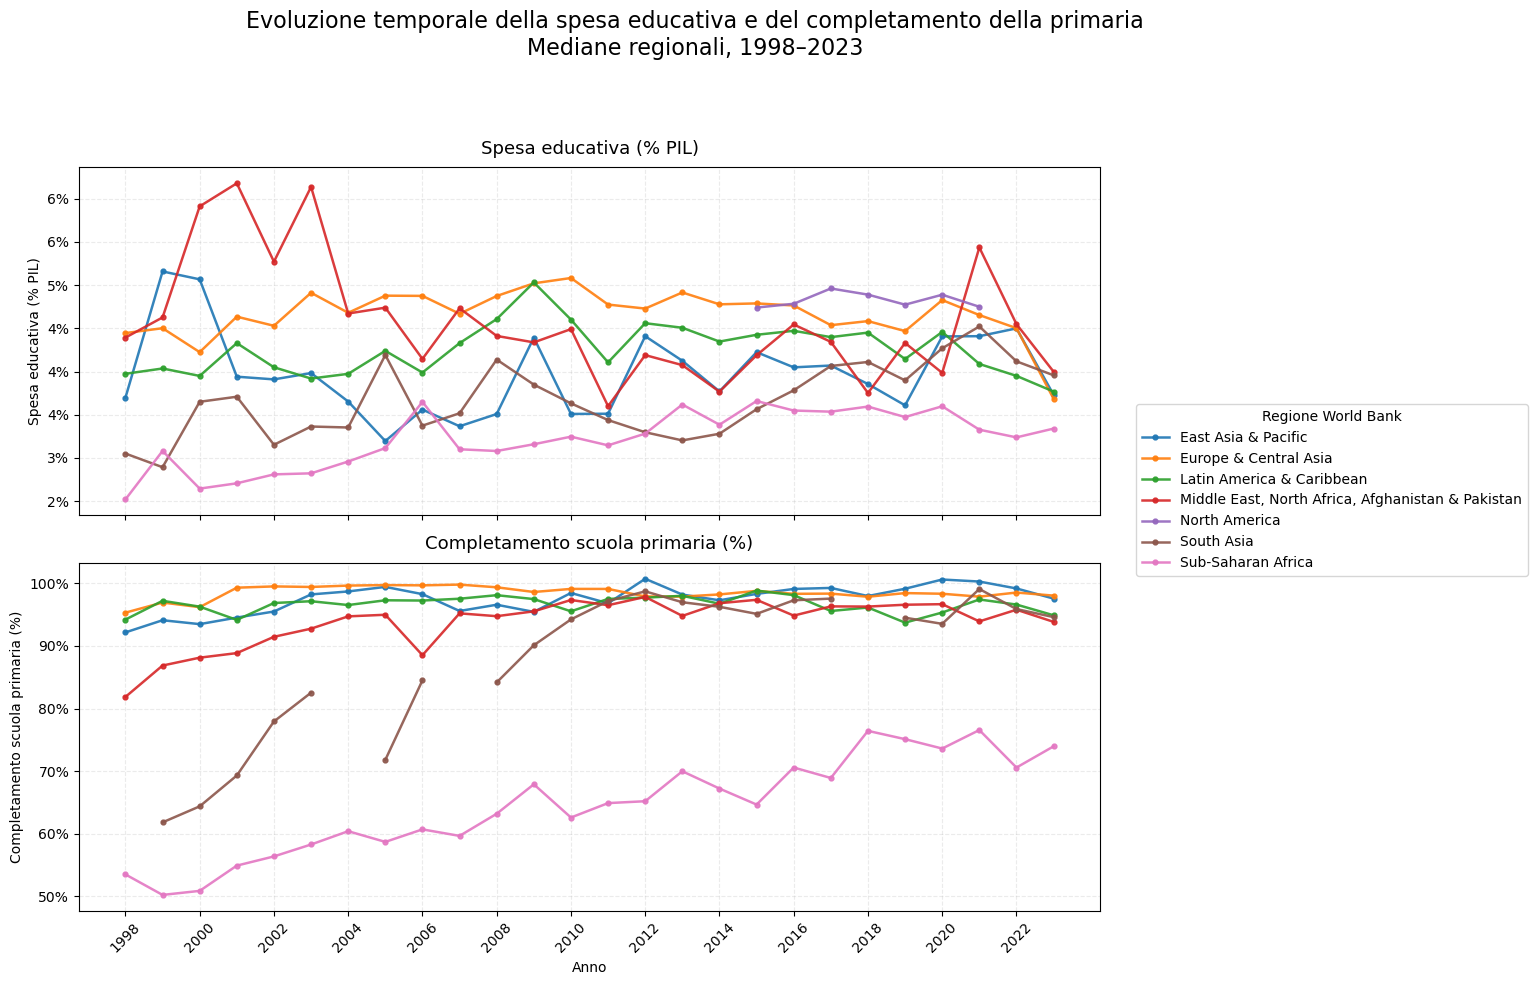

In [47]:
from matplotlib.ticker import FuncFormatter

#Definisco un ordine stabile delle regioni.
REGION_ORDER = sorted(panel_analysis["region"].dropna().unique())

#Associo in modo stabile un colore a ogni regione,mantenendolo identico nei due pannelli.
region_colors = dict( zip(REGION_ORDER,sns.color_palette("tab10",n_colors=len(REGION_ORDER))))

# Creo due pannelli verticali con lo stesso asse temporale.
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

for axis, (indicator, indicator_label) in zip(axes,TEMPORAL_INDICATORS.items()):

    indicator_trend = regional_annual_trends.loc[regional_annual_trends["indicator"] == indicator]

    #Disegno separatamente la linea di ogni regione.Matplotlib interrompe automaticamente la linea quando incontra un valore NaN.
    for region in REGION_ORDER:

        region_trend = (indicator_trend.loc[indicator_trend["region"] == region].sort_values("year") )

        axis.plot(
            region_trend["year"],
            region_trend["regional_median"],
            label=region,
            color=region_colors[region],
            linewidth=1.8,
            marker="o",
            markersize=3.5,
            alpha=0.90
        )

    axis.set_title(
        indicator_label,
        fontsize=13,
        pad=10
    )

    axis.set_ylabel(indicator_label)

    #Entrambi gli indicatori sono espressi in percentuale.
    axis.yaxis.set_major_formatter(FuncFormatter(lambda value, position:f"{value:.0f}%"))

    axis.grid(True,linestyle="--", alpha=0.25)

#Mostro un'etichetta temporale ogni due anni.
axes[-1].set_xticks(
    range(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR + 1,
        2
    )
)

axes[-1].tick_params(
    axis="x",
    rotation=45
)

axes[-1].set_xlabel("Anno")

fig.suptitle(
    "Evoluzione temporale della spesa educativa "
    "e del completamento della primaria\n"
    f"Mediane regionali, {ANALYSIS_START_YEAR}–"
    f"{ANALYSIS_END_YEAR}",
    fontsize=16
)

#Utilizzo una sola legenda per entrambi i pannelli.
legend_handles, legend_labels = (axes[0].get_legend_handles_labels())

fig.legend(
    legend_handles,
    legend_labels,
    title="Regione World Bank",
    loc="center left",
    bbox_to_anchor=(0.81, 0.50)
)

#Riservo spazio sulla destra per la legenda e nella parte superiore per il titolo.
plt.tight_layout(rect=[0, 0, 0.80, 0.93])

plt.show()

L’analisi temporale mostra che la spesa educativa presenta andamenti eterogenei e oscillazioni frequenti tra le regioni, senza una tendenza crescente comune all’intero periodo.
Il completamento della scuola primaria mostra invece un miglioramento più evidente.
Molte regioni raggiungono livelli prossimi al 95–100%, con una progressiva convergenza verso valori elevati.
South Asia e soprattutto Sub-Saharan Africa partono da livelli inferiori e registrano gli incrementi più rilevanti; tuttavia, Sub-Saharan Africa mantiene ancora un divario considerevole rispetto alle altre regioni.


Il confronto tra i pannelli non evidenzia una relazione temporale uniforme: aumenti o diminuzioni della spesa non sono sempre accompagnati da variazioni proporzionali del completamento. Il risultato suggerisce che la quota di PIL destinata all’istruzione costituisce solamente uno dei fattori associati ai risultati scolastici.

Possono influire anche l’efficienza nell’utilizzo delle risorse, la qualità delle istituzioni, le infrastrutture, le condizioni economiche e il livello iniziale di partecipazione scolastica.
Nelle regioni già vicine al completamento universale è inoltre presente un possibile effetto di saturazione, che limita ulteriori incrementi dell’indicatore.

## Conclusioni e raccomandazioni

L’obiettivo del progetto era comprendere, se e in quale misura, l’investimento pubblico nell’istruzione sia associato a migliori risultati educativi e, più in generale, alle condizioni economiche e sociali dei Paesi.

I risultati forniscono un sostegno parziale all’ipotesi iniziale:

- la spesa educativa in percentuale del PIL presenta una correlazione positiva con il completamento della scuola primaria e con l’iscrizione alla scuola secondaria, ma l’associazione non è particolarmente forte

- per il completamento della primaria, la correlazione complessiva rimane stabile intorno a 0,27 anche confrontando la spesa con il risultato osservato dopo tre e cinque anni

- per l’iscrizione secondaria, invece, la correlazione aumenta da circa 0,36 nello stesso anno a circa 0,40 dopo cinque anni

Quando l’analisi considera gli scostamenti dalla media di ciascun Paese, le associazioni diventano sensibilmente più deboli.
Per il completamento della primaria il coefficiente diminuisce da circa 0,14 a 0,09, mentre per l’iscrizione secondaria varia da circa 0,13 a 0,17. Questo indica che una parte importante delle correlazioni complessive dipende dalle differenze strutturali tra Paesi, più che da variazioni della spesa all’interno dello stesso Paese.

L’ipotesi secondo cui una maggiore spesa educativa sia associata a risultati migliori può quindi essere considerata parzialmente sostenuta, soprattutto per la partecipazione alla scuola secondaria.
I dati non supportano però una regola universale secondo cui un aumento della quota di PIL destinata all’istruzione produca automaticamente un miglioramento proporzionale dei risultati.

Le relazioni più forti del dataset non riguardano direttamente la spesa, ma la partecipazione scolastica e il livello generale di sviluppo. L’iscrizione alla scuola secondaria presenta una forte correlazione positiva con il PIL pro capite (ρ = 0,77) e con l’aspettativa di vita (ρ = 0,76), oltre a una forte associazione negativa con il tasso di fertilità (ρ = −0,71).
Questi risultati mostrano che istruzione, condizioni economiche, salute e dinamiche demografiche fanno parte di un sistema strettamente interconnesso. 

Non è tuttavia possibile stabilire una sola direzione causale: una maggiore istruzione può contribuire allo sviluppo economico e sociale, ma economie più solide e migliori condizioni di vita possono, a loro volta, favorire l’accesso all’istruzione.

L’analisi per livello di reddito conferma l’importanza del contesto: la correlazione tra iscrizione secondaria e PIL pro capite scende da 0,77 nel campione complessivo a 0,58 nei Paesi a basso reddito, 0,44 in quelli a reddito medio-basso, 0,34 in quelli a reddito medio-alto e 0,16 nei Paesi ad alto reddito.
La relazione complessiva è quindi in parte amplificata dalle differenze tra gruppi economici, considerando che nei Paesi ad alto reddito emerge un possibile effetto di saturazione, poiché la partecipazione scolastica ha già raggiunto livelli generalmente elevati.

Alla luce dei risultati, le politiche educative non dovrebbero concentrarsi esclusivamente sull’aumento della quota di PIL destinata all’istruzione: l’incremento delle risorse dovrebbe essere accompagnato da sistemi di monitoraggio capaci di valutarne l’allocazione, l’efficienza e i risultati effettivamente prodotti.

Nei Paesi e nelle regioni con livelli ancora bassi di partecipazione o completamento, le priorità dovrebbero riguardare accesso, continuità scolastica, infrastrutture, disponibilità degli insegnanti e riduzione degli abbandoni.
Nei sistemi già vicini alla partecipazione universale, l’attenzione dovrebbe spostarsi dalla quantità delle iscrizioni alla qualità dell’apprendimento, all’equità e alla capacità del sistema educativo di preparare gli studenti al mercato del lavoro.

Le strategie devono inoltre essere adattate al contesto economico e regionale, in quanto una stessa percentuale di PIL può corrispondere a risorse per studente molto differenti e produrre risultati diversi in base alla qualità delle istituzioni e dei servizi disponibili.

Per valutazioni future sarebbe quindi utile affiancare alla spesa in percentuale del PIL indicatori come la spesa per studente, la qualità dell’apprendimento, il tasso di abbandono e il completamento della scuola secondaria.

In conclusione, l’educazione emerge come una componente fondamentale dello sviluppo economico e sociale, ma il semplice aumento della quota di PIL destinata al settore non garantisce automaticamente risultati migliori.

Le evidenze indicano la necessità di combinare investimenti adeguati, utilizzo efficace delle risorse, politiche adattate al contesto e sistemi informativi più completi.

La priorità strategica non è quindi soltanto spendere di più, ma comprendere dove, come e con quali risultati vengono impiegate le risorse educative.